# Graded Codio Activity (Solution): Equipment Replacement as an MDP
A firm operates a machine that generates income and requires maintenance, both of which get worse as the machine ages. Every period the operator must decide whether to __keep__ the machine one more period or __replace__ it with a new one at a fixed cost. This keep-or-stop decision is a classic instance of __optimal stopping__, the same structure behind Rust's (1987) empirical model of Harold Zurcher's bus-engine replacement decisions, where a maintenance manager weighs the rising cost of an aging engine against the fixed cost of a new one. This notebook formulates the replacement decision as a finite MDP, solves it with both value iteration and policy iteration, and turns the converged policy into a replacement-age recommendation.

> __Learning Objectives.__
>
> This activity formulates a replacement decision as an MDP and solves it two ways:
> * __Formulate the replacement MDP:__ build the tuple $(\mathcal{S},\mathcal{A},T,R,\gamma)$ for the keep/replace decision with `build_replacement_mdp`.
> * __Solve via value iteration and policy iteration:__ compute $\pi^{\star}$ and $V^{\star}$ with both algorithms and confirm they agree.
> * __Recommend a replacement-age threshold:__ read the converged policy as a threshold age $a^{\star}$ and justify it in writing.

Let's get started.
___

## Theory: Equipment Replacement as an Optimal-Stopping MDP
We formalize the keep/replace decision as a finite MDP $(\mathcal{S},\mathcal{A},T,R,\gamma)$. The state is the machine's age, encoded as $s=a+1$ for $a\in\{0,1,\dots,\text{max\_age}\}$, so $\mathcal{S}=\{1,\dots,\text{max\_age}+1\}$. The action set is $\mathcal{A}=\{1,2\}$, with action $1$ = keep and action $2$ = replace; both transitions are deterministic (each row of $T$ is a point mass).

If the operator __keeps__ the machine at age $a$, income declines linearly with age while maintenance cost grows linearly with age:
$$
R(s,\text{keep}) = \big(\text{income}_{0} - \text{income\_decline}\cdot a\big) - \big(\text{maint}_{0} + \text{maint\_slope}\cdot a\big),
$$
and the machine ages deterministically to $a^{\prime}=\min(a+1,\text{max\_age})$, i.e., $T(s^{\prime}\mid s,\text{keep})=1$ for $s^{\prime}=a^{\prime}+1$.

If the operator __replaces__ the machine, it pays a fixed replacement cost and earns one period of a new machine's income net of upkeep:
$$
R(s,\text{replace}) = -\text{replace\_cost} + \big(\text{income}_{0}-\text{maint}_{0}\big),
$$
and the age resets deterministically to $a^{\prime}=1$, i.e., $T(s^{\prime}\mid s,\text{replace})=1$ for $s^{\prime}=2$.

With discount factor $\gamma\in[0,1)$, the Bellman optimality equation for this deterministic MDP reduces to a two-term maximum at every state:
$$
V^{\star}(s) = \max\Big(R(s,\text{keep}) + \gamma\,V^{\star}(s^{\prime}_{\text{keep}}),\; R(s,\text{replace}) + \gamma\,V^{\star}(s^{\prime}_{\text{replace}})\Big)\quad\forall s\in\mathcal{S}.
$$
__Value iteration__ applies the Bellman optimality backup $V_{k+1}=BV_{k}$ from $V_{0}=0$ until $\lVert V_{k+1}-V_{k}\rVert_{\infty}\le\epsilon$. __Policy iteration__ alternates exact policy evaluation $\mathbf{V}^{\pi}=(\mathbf{I}-\gamma\mathbf{P}^{\pi})^{-1}\mathbf{R}^{\pi}$ with greedy improvement $\pi^{\prime}(s)=\arg\max_{a}Q^{\pi}(s,a)$ until the policy is stable. Both are contraction-mapping fixed-point iterations on the same Bellman equation, so both must converge to the same $V^{\star}$ and $\pi^{\star}$.

Because "replace" always resets the state to a fixed, low age with a fixed reward, while "keep" moves the machine along a single trajectory of rising maintenance cost and falling income, the optimal policy for this class of problem is known to be a __threshold rule__: keep while $a<a^{\star}$, replace once $a\ge a^{\star}$, for some threshold age $a^{\star}\in\{0,1,\dots,\text{max\_age}\}$.
___

## Setup
This activity uses functions defined in the `src` directory and a small set of external packages. The `include(...)` call below runs `Include.jl`, which activates the local project environment, loads the packages, and includes our code. The first run may take a few minutes while packages are installed and precompiled.

In [1]:
include("Include.jl");

  Activating 

project at `~/Desktop/julia_work/CHEME-140-eCornell-Repository/courses/CHEME-145/module-4`


## Build the Replacement MDP
`build_replacement_mdp` constructs the MDP tuple $(\mathcal{S},\mathcal{A},T,R,\gamma)$ for the keep/replace decision described above. We build a machine that ages up to `max_age = 10`, starts with income $\text{income}_{0}=100$ that declines by $\text{income\_decline}=5$ per year of age, incurs maintenance starting at $\text{maint}_{0}=2$ and growing by $\text{maint\_slope}=5$ per year, and can be replaced at a fixed cost of $\text{replace\_cost}=60$, all discounted at $\gamma=0.9$.

In [2]:
mdp = build_replacement_mdp(; max_age = 10, income0 = 100.0, income_decline = 5.0,
    maint0 = 2.0, maint_slope = 5.0, replace_cost = 60.0, γ = 0.9);
(length(mdp.𝒮), length(mdp.𝒜))

(11, 2)

## Solve by Value Iteration
We configure a `MyValueIterationModel` with a sup-norm tolerance $\epsilon=10^{-9}$ and up to $10{,}000$ sweeps, then call `solve(...)`, which applies the Bellman optimality backup from $V_{0}=0$ until $\lVert V_{k+1}-V_{k}\rVert_{\infty}\le\epsilon$. The returned `sol_vi::MyValueFunctionPolicy` stores the converged value function in `sol_vi.V`; the greedy policy $\pi_{vi}(s)=\arg\max_{a}Q(s,a)$ is recovered with `policy(Q(mdp, sol_vi.V))`.

In [3]:
sol_vi = solve(build(MyValueIterationModel, (maxiterations = 10_000, ϵ = 1e-9)), mdp);
π_vi = policy(Q(mdp, sol_vi.V));

## Solve by Policy Iteration
We configure a `MyPolicyIterationModel` with a cap of 100 evaluate/improve cycles and call `solve(...)` on the same MDP, which alternates exact policy evaluation $\mathbf{V}^{\pi}=(\mathbf{I}-\gamma\mathbf{P}^{\pi})^{-1}\mathbf{R}^{\pi}$ with greedy improvement until the policy no longer changes. We compare the resulting greedy policy $\pi_{pi}$ to $\pi_{vi}$ element-wise.

In [4]:
sol_pi = solve(build(MyPolicyIterationModel, (maxiterations = 100,)), mdp);
π_pi = policy(Q(mdp, sol_pi.V));
println("policies agree: ", π_vi == π_pi);

policies agree: true

## The Replacement Threshold
Since $\pi_{vi}=\pi_{pi}$, we read the threshold age $a^{\star}$ directly off $\pi_{vi}$: it is the smallest age at which the optimal action is "replace" (action $2$).

In [5]:
a_star = minimum([ a for a ∈ 0:10 if π_vi[a+1] == 2 ]);
println("recommended policy: replace when age ≥ ", a_star);

recommended policy: replace when age ≥ 4


## Policy and Value Table
The table below lists, for every age $a\in\{0,\dots,10\}$, the optimal action $\pi^{\star}(a)$ ("keep" or "replace") and the optimal value $V^{\star}(a)$.

In [6]:
let
    rows = [ (a, π_vi[a+1] == 1 ? "keep" : "replace", round(sol_vi.V[a+1], digits = 2)) for a ∈ 0:10 ];
    data = permutedims(reduce(hcat, [collect(r) for r in rows]));
    pretty_table(data; column_labels = ["age a", "π*(a)", "V*(a)"]);
end

┌───────┬─────────┬────────┐
│ age a │   π*(a) │  V*(a) │
├───────┼─────────┼────────┤
│     0 │    keep │ 728.66 │
│     1 │    keep │ 700.73 │
│     2 │    keep │ 680.81 │
│     3 │    keep │ 669.79 │
│     4 │ replace │ 668.66 │
│     5 │ replace │ 668.66 │
│     6 │ replace │ 668.66 │
│     7 │ replace │ 668.66 │
│     8 │ replace │ 668.66 │
│     9 │ replace │ 668.66 │
│    10 │ replace │ 668.66 │
└───────┴─────────┴────────┘


## Visualize the Value Function and Threshold
The plot below shows the optimal value $V^{\star}(a)$ against machine age $a$, with a vertical line marking the replacement threshold $a^{\star}$.

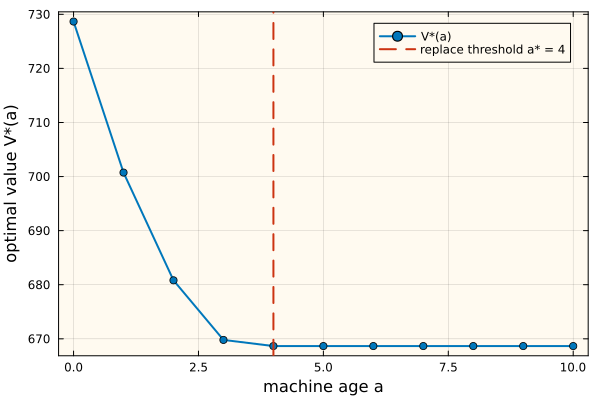

In [7]:
let
    plot(0:10, sol_vi.V, lw = 2, c = colors[1], marker = :circle, label = "V*(a)",
        bg = "floralwhite", background_color_outside = "white", framestyle = :box,
        xlabel = "machine age a", ylabel = "optimal value V*(a)");
    vline!([a_star], lw = 2, ls = :dash, c = colors[4], label = "replace threshold a* = $(a_star)")
end

## Recommendation
Both value iteration and policy iteration converge to the same optimal policy on this MDP (`policies agree: true`), which gives us confidence that $\pi^{\star}$ and $V^{\star}$ above are correct rather than an artifact of one algorithm. The converged policy is a threshold rule: keep the machine for ages $0$ through $3$, and replace it once it reaches age $a^{\star}=4$. Below that age, the machine's income still comfortably covers its maintenance cost, so the discounted value of keeping it another period exceeds the discounted value of paying to reset to a new one; from age $4$ onward, rising maintenance and falling income erode that margin enough that paying `replace_cost` and resetting to a young, cheap-to-run machine becomes optimal. This is exactly the optimal-stopping logic in Rust's (1987) bus-engine model: an operator facing a monotonically worsening running asset should stop and replace it as soon as its state crosses a fixed threshold, not wait until it fails outright. The actionable recommendation for this parameterization is therefore: __replace the machine at age 4__.

## Summary
This activity formulated the equipment-replacement decision as a finite MDP with age as the state and keep/replace as the actions, solved it with both value iteration and policy iteration, and translated the converged policy into a replacement-age recommendation.

Equipment replacement is an optimal-stopping problem, and value iteration and policy iteration solve it the same way any other finite MDP is solved: as a fixed point of the Bellman optimality equation.

> __Key Takeaways:__
>
> * **Replacement is an optimal-stopping MDP:** the state is machine age, "keep" advances the age along a single worsening trajectory, and "replace" resets the age at a fixed cost, matching the optimal-stopping structure of Rust's (1987) bus-engine model.
> * **Value iteration and policy iteration agree:** the two algorithms converge to the same optimal policy and value function on this MDP (`policies agree: true`), confirming both reach the same $\pi^{\star}$ and $V^{\star}$.
> * **The optimal policy is an actionable threshold:** the converged policy keeps the machine for ages $0$–$3$ and replaces it at age $a^{\star}=4$, turning the solved MDP directly into a replacement recommendation.

The equipment-replacement threshold found here is a direct consequence of the reward structure: once maintenance cost overtakes the benefit of avoiding the replacement cost, the optimal action switches and stays switched for every older age.
___

### Additional Resources
* Rust, J. (1987). Optimal replacement of GMC bus engines: An empirical model of Harold Zurcher. _Econometrica_, 55(5), 999–1033.
* Puterman, M. L. (1994). _Markov Decision Processes: Discrete Stochastic Dynamic Programming_. John Wiley & Sons.
* Sutton, R. S., & Barto, A. G. (2018). _Reinforcement Learning: An Introduction_ (2nd ed.). MIT Press.